In [21]:
import pandas as pd
import numpy as np
import bnlearn as bn
import time
import pickle

In [22]:
def load_data():
    """Load train and validation datasets from CSV files, and encode categorical features."""
    # Load datasets
    train_df = pd.read_csv('/content/drive/MyDrive/train_data.csv')
    val_df = pd.read_csv('/content/drive/MyDrive/validation_data.csv')

    # Define label mappings
    Distance_label = {"short": 1, "medium": 2, "long": 3}
    Fare_Category_label = {"Low": 1, "Medium": 2, "High": 3}

    # Apply label encoding to the categorical columns
    train_df['Distance'] = train_df['Distance'].map(Distance_label)
    train_df['Fare_Category'] = train_df['Fare_Category'].map(Fare_Category_label)

    val_df['Distance'] = val_df['Distance'].map(Distance_label)
    val_df['Fare_Category'] = val_df['Fare_Category'].map(Fare_Category_label)

    return train_df, val_df

In [23]:
def save_model(fname, model):
    """Save the model to a file using pickle."""
    with open(f"/content/drive/MyDrive/{fname}", 'wb') as f:
        pickle.dump(model, f)

In [24]:
def make_network(df):
    """Define and fit the initial Bayesian Network."""
    # Define the structure of the DAG as a list of edges
    dag = [
        # ('Start_Stop_ID', 'Fare_Category'),
        ('End_Stop_ID', 'Fare_Category'),
        ('Distance', 'Fare_Category'),
        ('Zones_Crossed', 'Fare_Category'),
        ('Route_Type', 'Fare_Category'),
        ('Start_Stop_ID', 'Distance'),
        ('End_Stop_ID', 'Distance'),
        ('Zones_Crossed', 'Distance'),
        ('Route_Type', 'Distance'),
        ('Start_Stop_ID','Zones_Crossed'),
        ('End_Stop_ID', 'Zones_Crossed'),
        ('Route_Type', 'Zones_Crossed'),
        ('Start_Stop_ID', 'Route_Type'),
        ('End_Stop_ID', 'Route_Type'),
        ('Start_Stop_ID', 'End_Stop_ID'),
    ]
    # Create Bayesian Network
    model = bn.make_DAG(dag)
    # Fit the Bayesian Network (define the CPDs based on the data)
    model = bn.parameter_learning.fit(model, df)
    bn.plot(model)
    # Return the fitted model
    return model

In [25]:
def make_pruned_network(df):
    """Define and fit a pruned Bayesian Network."""
    # Define the structure of the DAG as a list of edges
    dag = [
        ('Start_Stop_ID', 'Fare_Category'),
        ('End_Stop_ID', 'Fare_Category'),
        ('Distance', 'Fare_Category'),
        ('Zones_Crossed', 'Fare_Category'),
        ('Route_Type', 'Fare_Category'),
        ('Start_Stop_ID', 'Distance'),
        ('End_Stop_ID', 'Distance'),
        ('Zones_Crossed', 'Distance'),
        ('Route_Type', 'Distance'),
        ('Start_Stop_ID','Zones_Crossed'),
        ('End_Stop_ID', 'Zones_Crossed'),
        ('Route_Type', 'Zones_Crossed'),
        ('Start_Stop_ID', 'Route_Type'),
        ('End_Stop_ID', 'Route_Type'),
        ('Start_Stop_ID', 'End_Stop_ID'),
    ]

    pruned_dag = []
    egdes_pruned = []
    # Edge pruning based on correlation less than correlation_threshold
    correlation_threshold = 0.4
    # Compute correlation matrix
    corr_matrix = df.corr()
    for edge in dag:
        node1, node2 = edge
        # Check if nodes exist in the correlation matrix
        if node1 in corr_matrix.columns and node2 in corr_matrix.columns:
            corr_value = abs(corr_matrix.loc[node1, node2])  # Get the absolute correlation value
            if corr_value >= correlation_threshold:
                pruned_dag.append(edge)  # Keep edge if correlation is >= 0.4
            else:
                egdes_pruned.append(edge)

    print(f"Edges pruned: {egdes_pruned}")

    # Create Bayesian Network with pruned DAG
    model = bn.make_DAG(pruned_dag)
    # Fit the Bayesian Network (define the CPDs based on the data)
    model = bn.parameter_learning.fit(model, df)
    bn.plot(model)
    # Return the pruned and fitted model
    return model

In [26]:
def make_optimized_network(df):
    """Perform structure optimization and fit the optimized Bayesian Network."""
    # Define the structure of the DAG as a list of edges
    dag = [
        ('Start_Stop_ID', 'Fare_Category'),
        ('End_Stop_ID', 'Fare_Category'),
        ('Distance', 'Fare_Category'),
        ('Zones_Crossed', 'Fare_Category'),
        ('Route_Type', 'Fare_Category'),
        ('Start_Stop_ID', 'Distance'),
        ('End_Stop_ID', 'Distance'),
        ('Zones_Crossed', 'Distance'),
        ('Route_Type', 'Distance'),
        ('Start_Stop_ID','Zones_Crossed'),
        ('End_Stop_ID', 'Zones_Crossed'),
        ('Route_Type', 'Zones_Crossed'),
        ('Start_Stop_ID', 'Route_Type'),
        ('End_Stop_ID', 'Route_Type'),
        ('Start_Stop_ID', 'End_Stop_ID'),
    ]
    # Apply structure learning (Hill Climbing) to refine the network
    model = bn.structure_learning.fit(df, methodtype='hc',bw_list_method='edges',white_list=dag)
    # Learn the parameters (CPDs) for the refined network
    model = bn.parameter_learning.fit(model, df)
    bn.plot(model)
    # Return the refined model
    return model

In [27]:
train_df, val_df = load_data()

[bnlearn] >bayes DAG created.
[bnlearn] >Parameter learning> Computing parameters using [bayes]
[bnlearn] >CPD of End_Stop_ID:
+--------------------+-----------------------+-----+----------------------+
| Start_Stop_ID      | Start_Stop_ID(111)    | ... | Start_Stop_ID(22679) |
+--------------------+-----------------------+-----+----------------------+
| End_Stop_ID(27)    | 0.0018375327080822036 | ... | 0.005784024524263977 |
+--------------------+-----------------------+-----+----------------------+
| End_Stop_ID(111)   | 0.0018375327080822036 | ... | 0.005784024524263977 |
+--------------------+-----------------------+-----+----------------------+
| End_Stop_ID(145)   | 0.0018375327080822036 | ... | 0.005784024524263977 |
+--------------------+-----------------------+-----+----------------------+
| End_Stop_ID(184)   | 0.0018375327080822036 | ... | 0.005784024524263977 |
+--------------------+-----------------------+-----+----------------------+
| End_Stop_ID(215)   | 0.001837532708

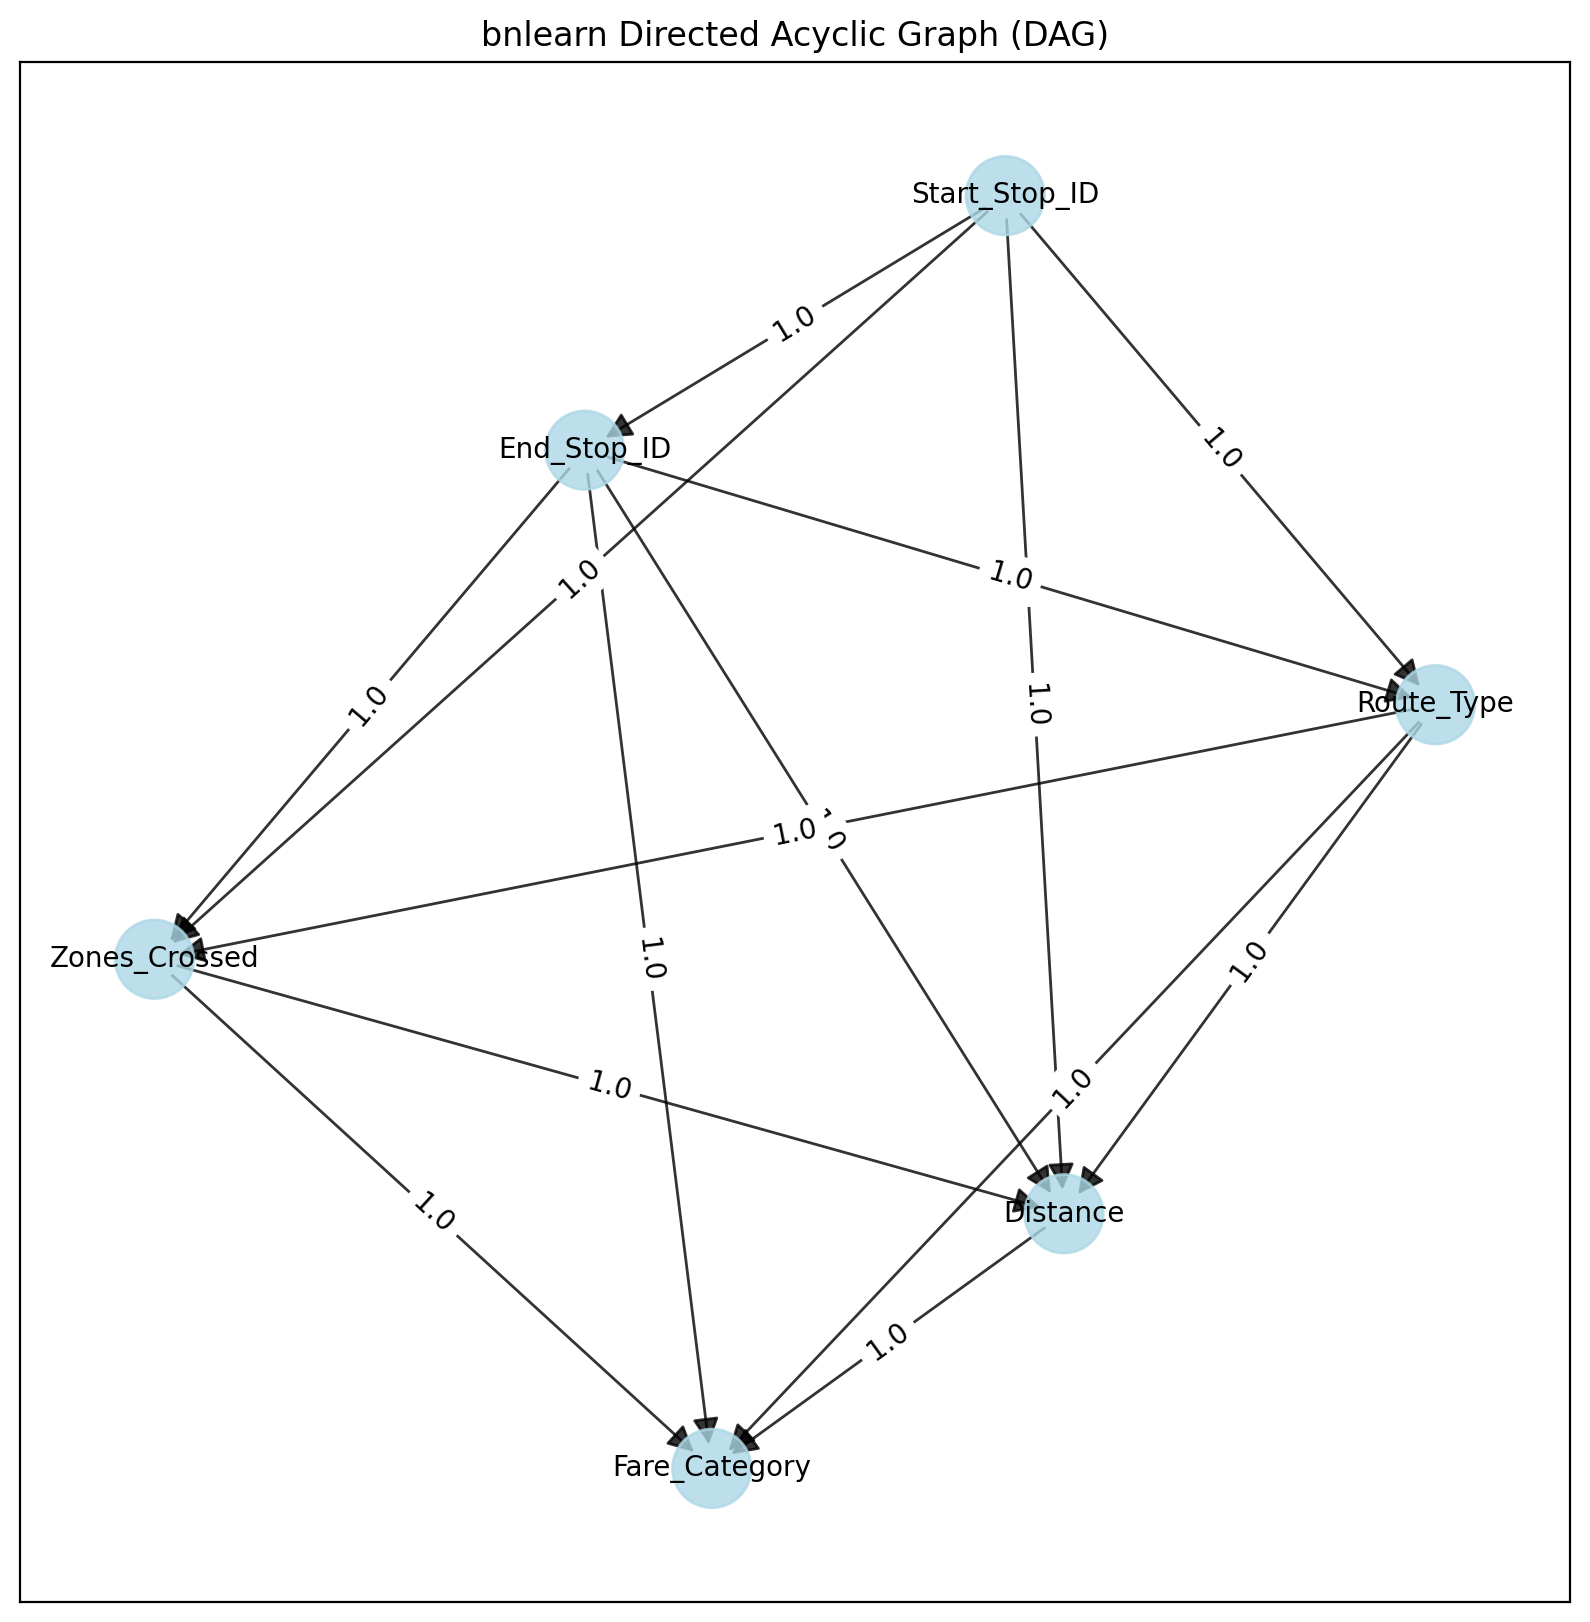

Time taken to construct and fit the base Bayesian Network: 242.45 seconds


In [28]:
start_time = time.time()
base_model = make_network(train_df)
end_time = time.time()
print(f"Time taken to construct and fit the base Bayesian Network: {end_time - start_time:.2f} seconds")
save_model("base_model.pkl", base_model)


Edges pruned: [('Start_Stop_ID', 'Fare_Category'), ('Route_Type', 'Fare_Category'), ('Start_Stop_ID', 'Distance'), ('Route_Type', 'Distance'), ('Start_Stop_ID', 'Zones_Crossed'), ('Route_Type', 'Zones_Crossed'), ('Start_Stop_ID', 'Route_Type'), ('End_Stop_ID', 'Route_Type'), ('Start_Stop_ID', 'End_Stop_ID')]
[bnlearn] >bayes DAG created.
[bnlearn] >Removing columns from dataframe to make consistent with DAG [['Start_Stop_ID' 'Route_Type']]
[bnlearn] >Parameter learning> Computing parameters using [bayes]
[bnlearn] >CPD of End_Stop_ID:
+--------------------+------------+
| End_Stop_ID(27)    | 0.00478303 |
+--------------------+------------+
| End_Stop_ID(111)   | 0.00719266 |
+--------------------+------------+
| End_Stop_ID(145)   | 0.024783   |
+--------------------+------------+
| End_Stop_ID(184)   | 0.00550592 |
+--------------------+------------+
| End_Stop_ID(215)   | 0.018036   |
+--------------------+------------+
| End_Stop_ID(239)   | 0.00839748 |
+--------------------+-----

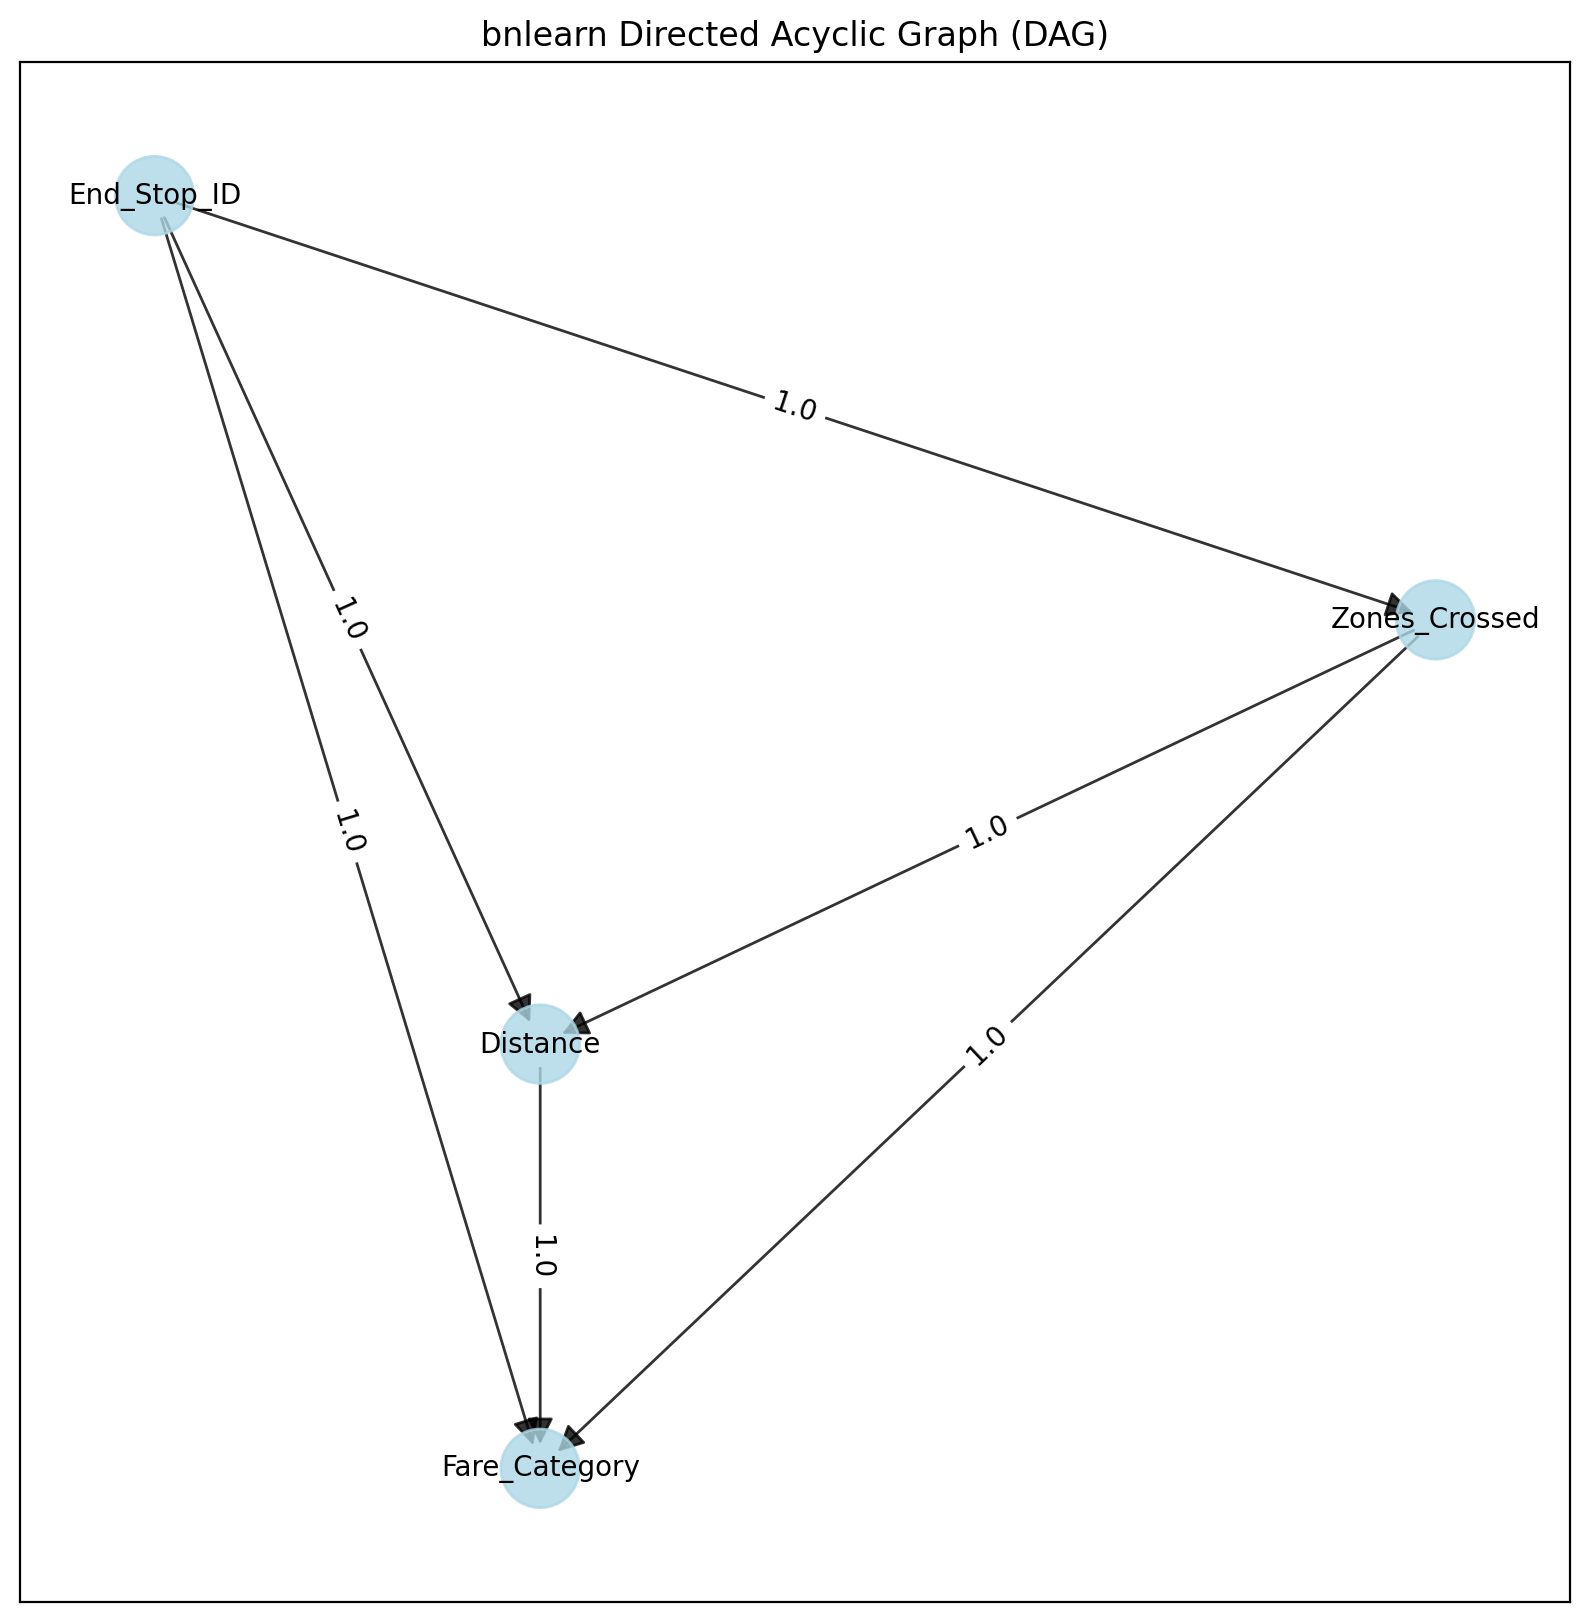

Time taken to construct and fit the Pruned Bayesian Network: 14.42 seconds


In [29]:
start_time = time.time()
pruned_network = make_pruned_network(train_df)
end_time = time.time()
print(f"Time taken to construct and fit the Pruned Bayesian Network: {end_time - start_time:.2f} seconds")
save_model("pruned_model.pkl", pruned_network)


[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Filter edges based on black_list/white_list
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Parameter learning> Computing parameters using [bayes]
[bnlearn] >Converting [<class 'pgmpy.base.DAG.DAG'>] to BayesianNetwork model.
[bnlearn] >Converting adjmat to BayesianNetwork.
[bnlearn] >CPD of Distance:
+---------------+---------------------+-----+----------------------+
| Zones_Crossed | Zones_Crossed(38)   | ... | Zones_Crossed(22535) |
+---------------+---------------------+-----+----------------------+
| Distance(1)   | 0.8564764980265519  | ... | 0.08120178643930166  |
+---------------+---------------------+-----+----------------------+
| Distance(2)   | 0.07176175098672408 | ... | 0.08120178643930166  |
+---------------+---------------------+-----+----------------------+
| Distance(3)   | 0.07176175098672408 | ... | 0.8375964271213967   |
+---------------

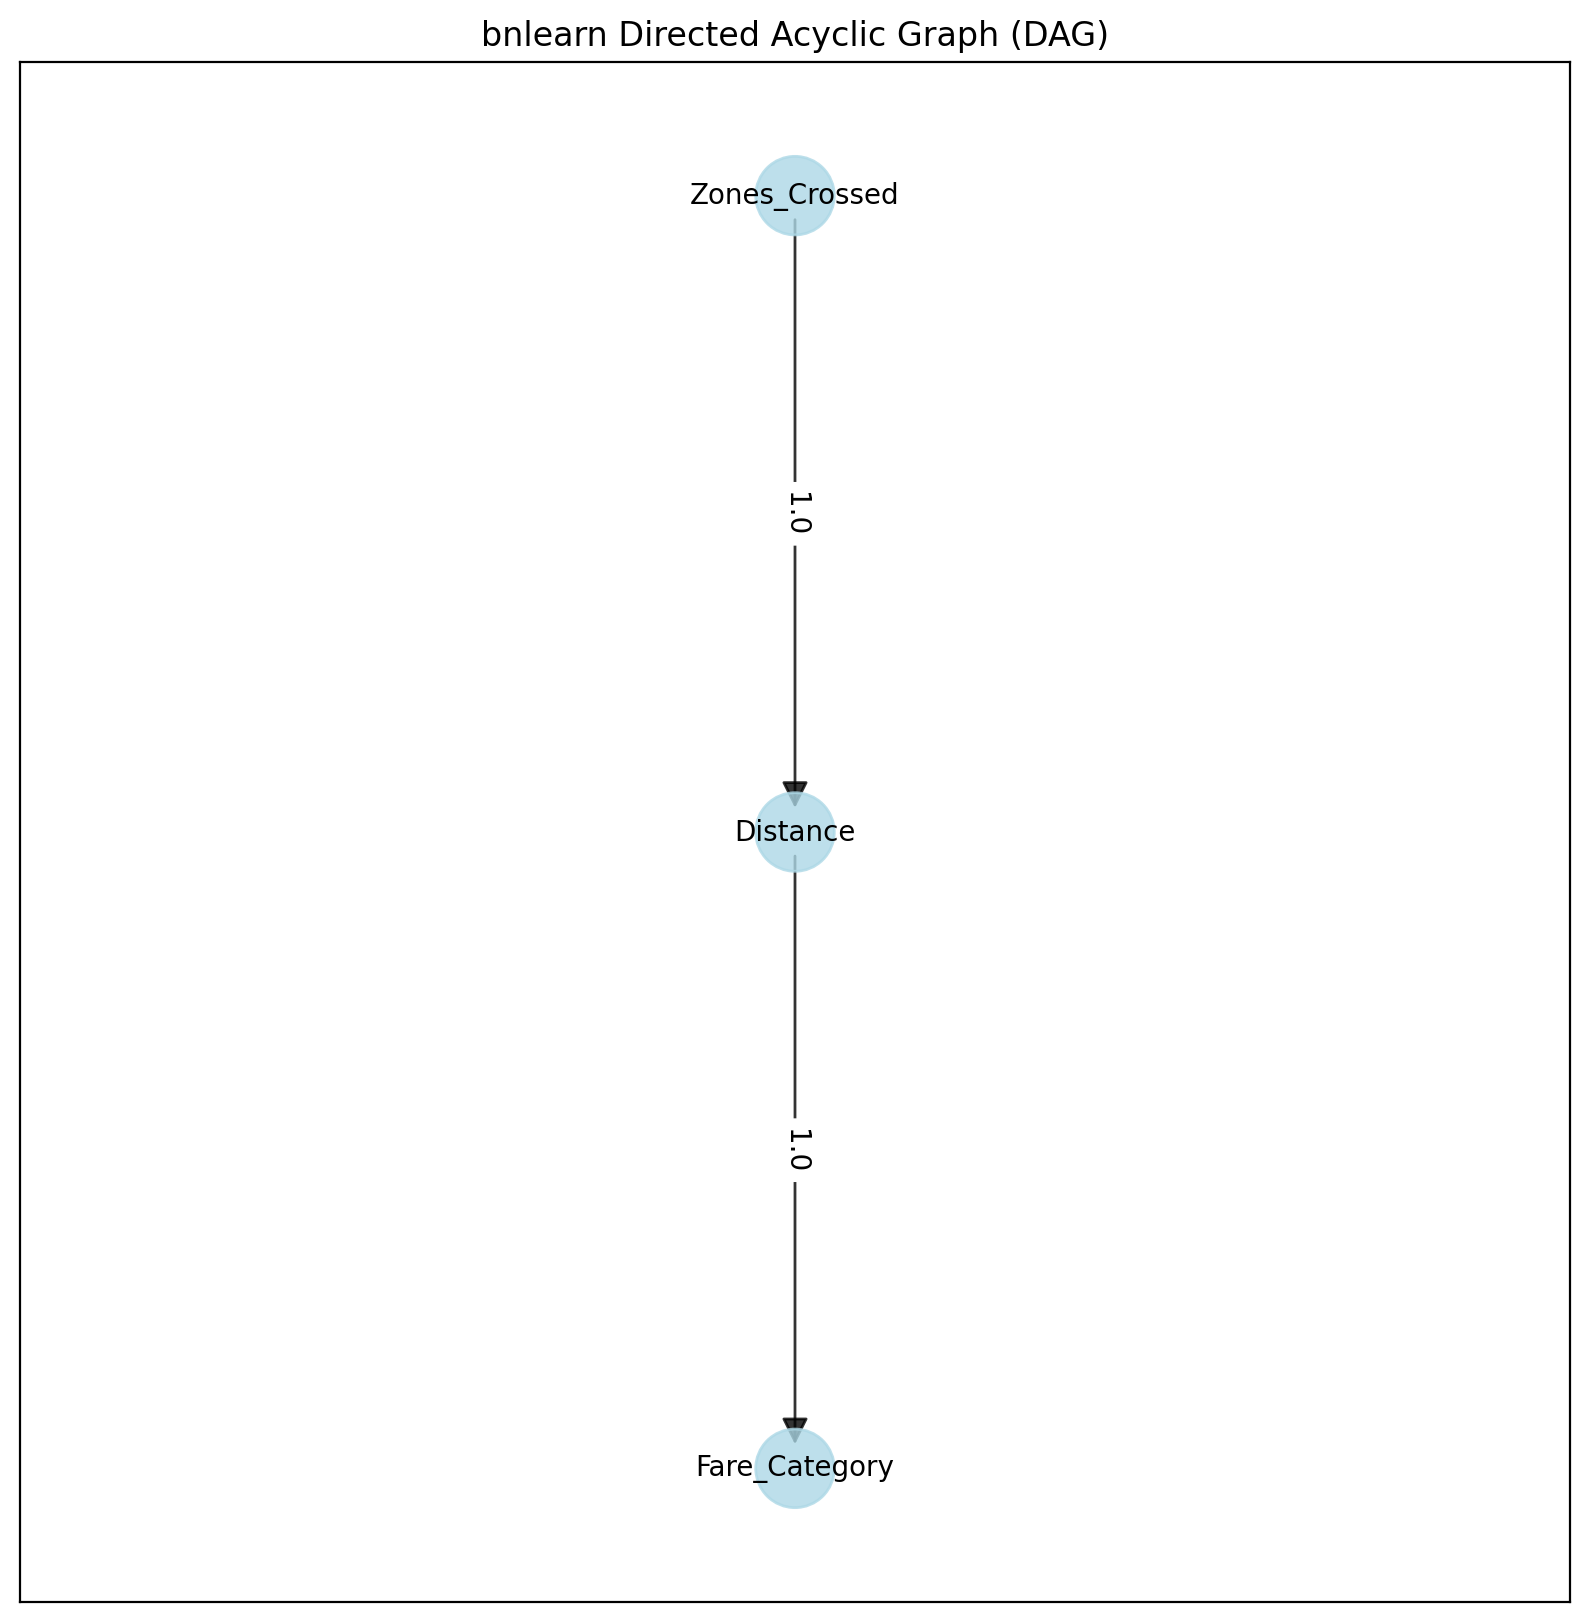

Time taken to construct and fit the optimized Bayesian Network: 0.64 seconds


In [30]:
start_time = time.time()
optimized_network = make_optimized_network(train_df)
end_time = time.time()
print(f"Time taken to construct and fit the optimized Bayesian Network: {end_time - start_time:.2f} seconds")
save_model("optimized_model.pkl", optimized_network)